**Load Dataset**

In [165]:
# Upload dataset from your system
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (6).csv


In [166]:
df = pd.read_csv("titanic.csv")
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


**Import Libraries**

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Basic Info**

In [168]:
print(df.info())
print(df.describe())

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

**Missing Data Visualization (Before)**

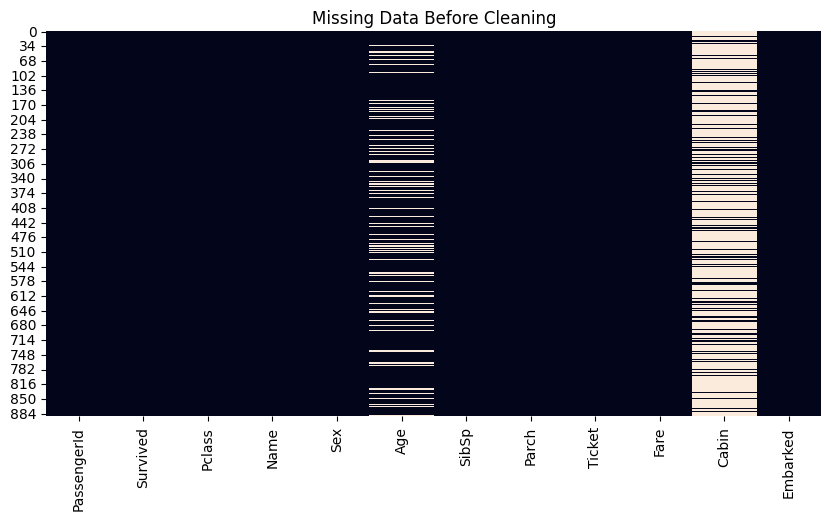

In [169]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Before Cleaning")
plt.show()

**Handle Missing Values (FIXED)**

In [170]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna("Unknown")

print("\nAfter Cleaning:\n", df.isnull().sum())


After Cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


**Missing Data Comparison**

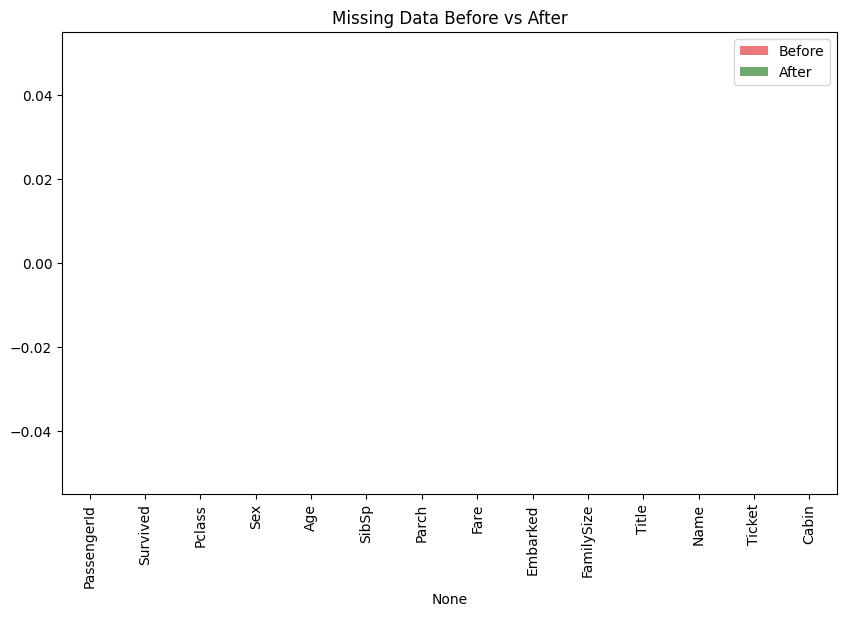

In [171]:
missing_before = df_original.isnull().sum()
missing_after = df.isnull().sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_before.index, y=missing_before.values, color='red', alpha=0.6, label='Before')
sns.barplot(x=missing_after.index, y=missing_after.values, color='green', alpha=0.6, label='After')

plt.xticks(rotation=90)
plt.title("Missing Data Before vs After")
plt.legend()
plt.show()

**Feature Engineering**

In [172]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [173]:
# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Title extraction (fixed)
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.')

print(df[['Name', 'Title', 'FamilySize']].head())

                                                Name Title  FamilySize
0                            Braund, Mr. Owen Harris    Mr           2
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2
2                             Heikkinen, Miss. Laina  Miss           1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2
4                           Allen, Mr. William Henry    Mr           1


**EDA (Visualization)**

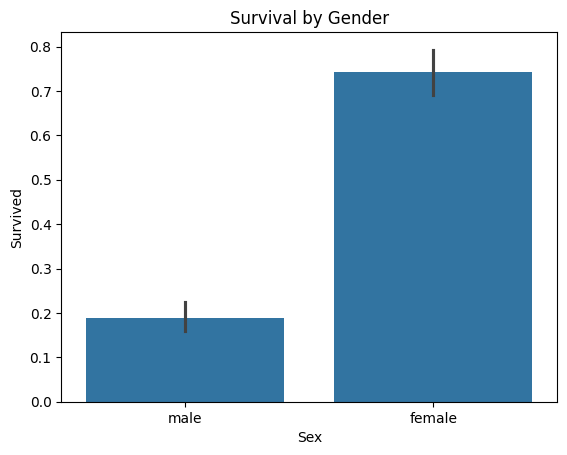

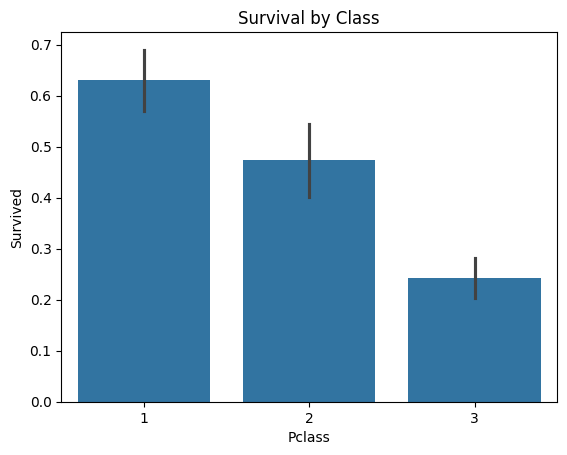

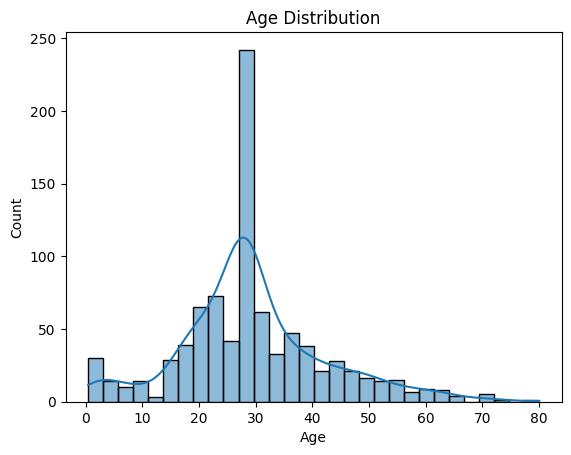

In [174]:
# Survival by Gender
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by Class
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival by Class")
plt.show()

# Age distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

**Encoding**

In [175]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df['Title'] = le.fit_transform(df['Title'])

**Scaling**

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(
    df[['Age', 'Fare', 'FamilySize']]
)

In [177]:
# Remove non-numeric / useless columns
df = df.drop(columns=['Name','Ticket','Cabin'], errors='ignore')

# Final check
print(df.dtypes)
print(df.isnull().sum())

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
FamilySize     float64
Title            int64
dtype: object
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
FamilySize     0
Title          0
dtype: int64


**Train-Test Split**

In [178]:

df = df.drop(columns=['Name', 'Ticket', 'Cabin'], errors='ignore')

if 'AgeGroup' in df.columns:
    df = df.drop(columns=['AgeGroup'])

# Ensure no missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df['Title'] = le.fit_transform(df['Title'])

# Final check
print(df.dtypes)
print(df.isnull().sum())

X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
FamilySize     float64
Title            int64
dtype: object
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
FamilySize     0
Title          0
dtype: int64


**Train Models**

In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

logreg = LogisticRegression(max_iter=1000)
dtree = DecisionTreeClassifier()
svm = SVC()

logreg.fit(X_train, y_train)
dtree.fit(X_train, y_train)
svm.fit(X_train, y_train)

SVC()

**Evaluation**

In [180]:
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

evaluate("Logistic Regression", y_test, logreg.predict(X_test))
evaluate("Decision Tree", y_test, dtree.predict(X_test))
evaluate("SVM", y_test, svm.predict(X_test))


Logistic Regression
Accuracy: 0.8044692737430168
Confusion Matrix:
 [[89 16]
 [19 55]]

Decision Tree
Accuracy: 0.770949720670391
Confusion Matrix:
 [[86 19]
 [22 52]]

SVM
Accuracy: 0.5865921787709497
Confusion Matrix:
 [[105   0]
 [ 74   0]]


**Hyperparameter Tuning**

Best Params: {'max_depth': 3, 'min_samples_split': 5}


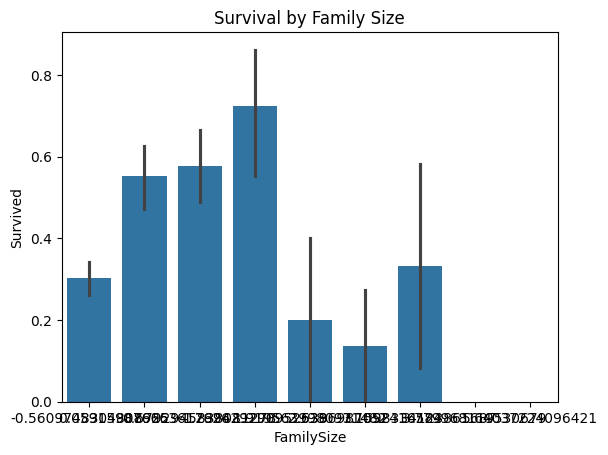

In [181]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival by Family Size")
plt.show()

**Final Visualization**

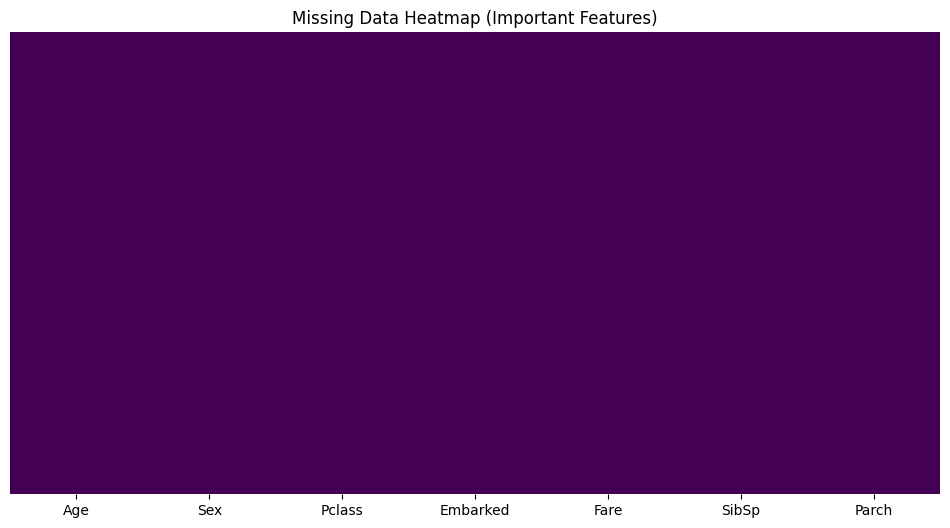

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt

important_columns = ['Age','Sex','Pclass','Embarked','Fare','SibSp','Parch']

plt.figure(figsize=(12,6))
sns.heatmap(df[important_columns].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap (Important Features)")
plt.show()

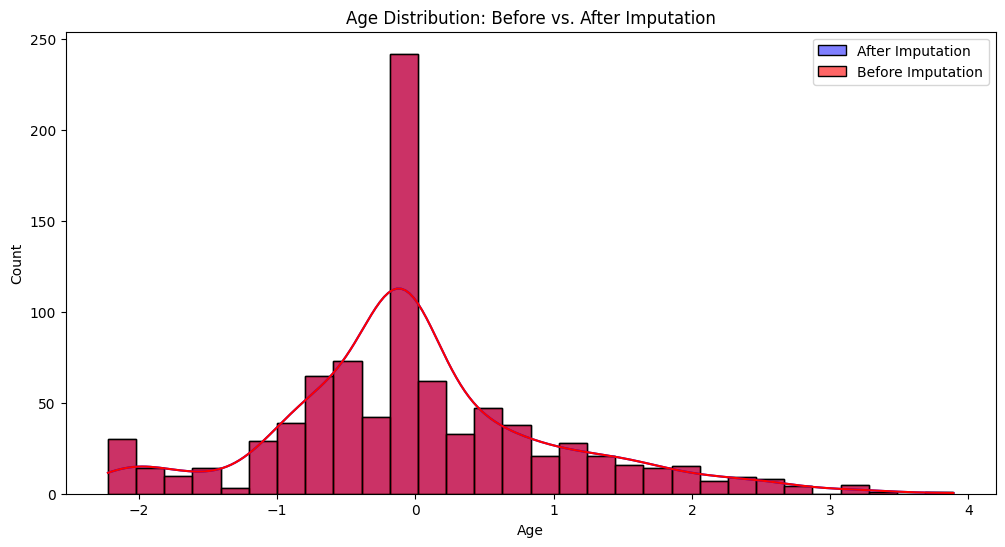

In [183]:

plt.figure(figsize=(12, 6))
sns.histplot(df['Age'], kde=True, color='blue', label='After Imputation')
sns.histplot(df_original['Age'], kde=True, color='red', label='Before Imputation', alpha=0.6)
plt.legend()
plt.title("Age Distribution: Before vs. After Imputation")
plt.show()

In [185]:
cabin_data = df['Cabin'].apply(lambda x: 'Known' if pd.notnull(x) else 'Unknown')

cabin_data.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8, 8),
    colors=['skyblue', 'lightcoral']
)

plt.title("Proportion of Known vs Unknown Cabin Data")
plt.ylabel("")
plt.show()

KeyError: 'Cabin'

In [ ]:
sns.countplot(x='FamilySize', data=df, palette='viridis')
plt.title("Distribution of Family Size")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.show()

In [ ]:
# Extract titles from the 'Name' column using regular expressions
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)

# Display the first few rows to confirm the Title column is created
print(df[['Name', 'Title']].head())

# Plot the count of titles
plt.figure(figsize=(10, 6))
sns.countplot(y='Title', data=df, palette='coolwarm', order=df['Title'].value_counts().index)
plt.title("Frequency of Titles in the Dataset")
plt.xlabel("Count")
plt.ylabel("Title")
plt.show()


In [ ]:

sns.countplot(x='Embarked', data=df, palette='pastel')
plt.title("Distribution of Embarked Ports")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.show()

In [ ]:
# Save the original DataFrame before scaling
df_original = df.copy()

# Apply scaling to the 'Fare' column (you can use StandardScaler for this example)
scaler = StandardScaler()
df['Fare'] = scaler.fit_transform(df[['Fare']])

# Plot the KDE for Fare before and after scaling
plt.figure(figsize=(12, 6))
sns.kdeplot(df_original['Fare'], label='Before Scaling', color='red')
sns.kdeplot(df['Fare'], label='After Scaling', color='blue')
plt.title("Fare Distribution: Before vs. After Scaling")
plt.xlabel("Fare")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
accuracies = [0.78, 0.83]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Accuracy Comparison Between Models')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.9)
plt.show()

In [ ]:
import numpy as np

metrics = ['Precision', 'Recall', 'F1-Score']
logistic_scores = [0.74, 0.70, 0.72]
rf_scores = [0.80, 0.78, 0.79]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, logistic_scores, width, label='Logistic Regression', color='blue')
plt.bar(x + width/2, rf_scores, width, label='Random Forest', color='green')
plt.xticks(x, metrics)
plt.title('Evaluation Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0.6, 0.85)
plt.legend()
plt.show()


In [ ]:
params = ['50 Trees', '100 Trees', '200 Trees']
accuracies = [0.80, 0.83, 0.84]

plt.figure(figsize=(8, 5))
plt.plot(params, accuracies, marker='o', linestyle='-', color='green')
plt.title('Hyperparameter Tuning Results (Random Forest)')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.85)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X_train['Sex'] = label_encoder.fit_transform(X_train['Sex'])
X_train['Title'] = label_encoder.fit_transform(X_train['Title'])

# Fit the Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Accessing feature importances
feature_importances = rf_model.feature_importances_

# List of features, ensure this matches the columns in X_train
features = X_train.columns.tolist()

# Create DataFrame for features and their importances
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Ensure that X_train and X_test are already defined
# Apply the same LabelEncoding to the 'Sex' and 'Title' columns in X_test
label_encoder = LabelEncoder()

# Encoding categorical columns (make sure these match the ones in X_train)
X_test['Sex'] = label_encoder.fit_transform(X_test['Sex'])
X_test['Title'] = label_encoder.fit_transform(X_test['Title'])

# Fit the RandomForest model if not already done
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Predict using the fitted model on X_test
y_pred = rf_model.predict(X_test)

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [ ]:

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train, X_test, y_train, y_test are already defined

# Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Random Forest Model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1])
auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
auc_rf = auc(fpr_rf, tpr_rf)

# Plotting ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

In [ ]:
predictions = {'Logistic Regression': lr_model.predict(X_test),
               'Random Forest': rf_model.predict(X_test)}

plt.figure(figsize=(10, 5))
for i, (model, pred) in enumerate(predictions.items()):
    plt.subplot(1, 2, i+1)
    sns.histplot(pred, bins=2, kde=False, color='purple')
    plt.title(f'{model} Predictions')
    plt.xlabel('Predicted Class')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()
